# Module 3 — Statistical Foundations: Significance, CIs, Power & Sample Size

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - Hypothesis testing mechanics: null/alternative, p-values, significance level, confidence intervals (CI)
> - Type I vs. Type II error, and the tradeoff between them
> - Statistical power, and what drives it (effect size, sample size, variance, alpha)
> - Choosing a test: two-proportion z-test (conversion rate), t-test (continuous metrics like revenue or session length), chi-square for categorical outcomes, and where normality assumptions break down (e.g. heavy-tailed revenue data)
> - Sample size / Minimum Detectable Effect (MDE) calculations, and the practical tension between "how long can we run this" and "what effect can we actually detect"
>
> **Why it matters**
> This is the technical core interviewers screen for, and the toolkit every later module depends on — you can't design a properly sized test (Module 4) or reason about peeking (Module 5) without it.
>
> **Worked example**
> Baseline checkout conversion is 5%, and the team wants to detect a lift to 5.5% (a 10% relative lift) with 80% power at a 5% significance level. Plugging these into the standard two-proportion sample-size formula gives a required sample per arm in the tens of thousands — small relative lifts on already-low base rates need surprisingly large samples. We'll implement this formula in Python as this module's exercise so you get the exact number, not just the intuition.
>
> **Resources**
> - [Evan Miller's Sample Size Calculator](https://www.evanmiller.org/ab-testing/sample-size.html) (verified, interactive, ~10 min)
> - *Trustworthy Online Controlled Experiments* — Kohavi, Tang, Xu, Ch. 3 (~30 min) — no free web version for this chapter (unlike Ch. 1 in Module 1); requires the book itself, hence no link here.
>
> **Exercise type:** computational — implement power/sample-size calculators from scratch in Python, then simulate experiments (known true effect) to verify your test correctly detects it at the expected rate.
>
> **Interview angle:** live stats questions, sample-size case questions ("we get 10k signups/day, 5% baseline conversion, want to detect a 2pp lift — how long do we run it?").

## Lesson

### Hypothesis testing mechanics

Every A/B test starts with a **null hypothesis** (H₀: no true difference between control and treatment) and an **alternative hypothesis** (H₁: there is a difference). You never directly prove H₁ — you gather evidence and ask "how surprising would this data be if H₀ were actually true?" The **p-value** answers exactly that: the probability of seeing a result at least as extreme as what you observed, *if the null hypothesis were true*. A small p-value means the observed data would be a surprising coincidence under H₀ — evidence against it, not proof of H₁.

The **significance level (α)**, almost always 5%, is the p-value threshold below which you're willing to call a result "statistically significant" — it's a policy choice about how much false-positive risk you'll tolerate, not a property of the data. A **confidence interval (CI)** is the companion to the p-value: instead of a single yes/no significance call, it gives a plausible range for the true effect size. A 95% CI has a precise (if often misstated) meaning: if you repeated this experiment many times, 95% of the intervals constructed this way would contain the true effect. It's more informative than a p-value alone because it also shows *how big* the effect plausibly is, not just whether it's distinguishable from zero.

### Type I vs. Type II error

Two ways to be wrong: a **Type I error** (false positive) rejects H₀ when it's actually true — you ship a change that does nothing. A **Type II error** (false negative) fails to reject H₀ when H₁ is actually true — you kill a change that actually worked. α is your Type I error rate by construction (that's literally what "significance level" controls). **β** is the Type II error rate, and **power (1 − β)** is the probability of correctly detecting a true effect when one exists. The two error types trade off: tightening α (fewer false positives) makes it harder to reach significance at all, which — holding everything else fixed — increases β (more false negatives, lower power). You don't get to shrink both simultaneously without paying for it elsewhere (bigger sample, bigger effect).

### Statistical power and what drives it

**Power, in plain terms, is the probability your test actually catches a real effect if one truly exists** — run the same experiment 100 times with a real effect present, and at 80% power roughly 80 of those runs come back significant, 20 miss it purely from random noise. Power depends on four things: a **bigger true effect size** is easier to detect (higher power); **more sample size** shrinks the noise around your estimate (higher power); **more underlying variance** in the metric makes any given sample noisier (lower power); and a **looser α** makes it easier to cross the significance bar (higher power, but more false positives — see above). In practice, effect size and variance are properties of the world you don't control; sample size is usually the one lever you *can* pull, which is exactly why sample-size/MDE calculations (below) matter so much.

### Choosing the right test

- **Two-proportion z-test** — for a binary outcome (each person is just one of two things — converted or didn't, clicked or didn't — not a number), comparing one group's percentage against another's. Like most primary metrics in this program (checkout completion, activation, signup).
- **t-test** — for a continuous metric (revenue, session length, time-on-page). Relies on the sampling distribution of the *mean* being approximately normal, which the Central Limit Theorem gives you even for non-normal underlying data — but only once your sample is "large enough," and revenue-like data is often heavy-tailed (a small share of high-spending users dominate the variance), which pushes out how large "large enough" really is.
- **Chi-square test** — for a categorical outcome with more than two levels (e.g. which of three subscription tiers a user picks), where a single proportion doesn't capture the full picture.

### Sample size and MDE

For a fixed power and α, there's a direct three-way tradeoff: a **smaller MDE** (you want to detect a subtler effect) requires a **larger sample size** — and by extension, more calendar time at a given traffic volume. This is the practical tension product teams live with constantly: "how long do we run this" and "what effect can we actually detect" are the same question asked two different ways. The worked example below makes this concrete.

### Part 1 — Visualizing power, α, and β

The classic picture: the null distribution (H₀, centered at 0) and the alternative distribution (H₁, shifted right by the true effect, in standardized units) both plotted together. Everything in this module's math traces back to this one picture.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=123)

BLUE = "#2a78d6"    # H0 / control
ORANGE = "#eb6834"  # H1 / treatment
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

z(alpha/2) = 1.960, z(power) = 0.842, required standardized effect for 80% power = 2.802


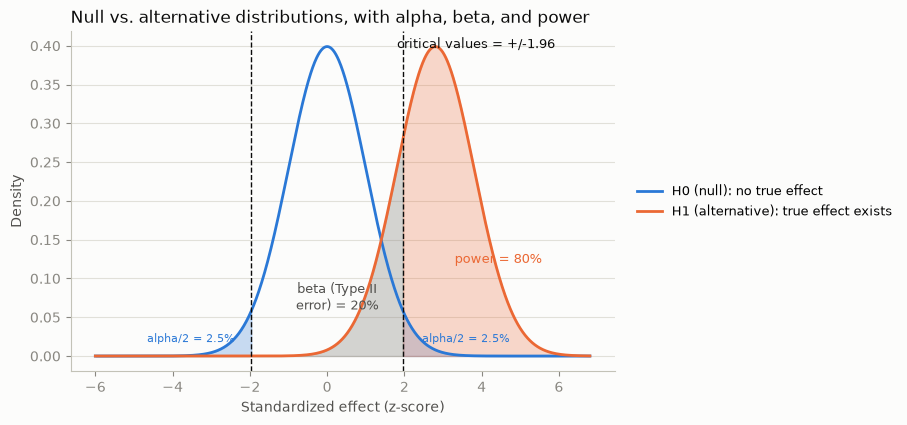

In [2]:
alpha = 0.05
target_power = 0.80

z_alpha_2 = stats.norm.ppf(1 - alpha / 2)   # two-sided critical value, ~1.96 (EACH tail holds alpha/2)
z_power = stats.norm.ppf(target_power)      # ~0.84

standardized_effect = z_alpha_2 + z_power
print(f"z(alpha/2) = {z_alpha_2:.3f}, z(power) = {z_power:.3f}, "
      f"required standardized effect for 80% power = {standardized_effect:.3f}")

x = np.linspace(-6, standardized_effect + 4, 1000)
h0_pdf = stats.norm.pdf(x, loc=0, scale=1)
h1_pdf = stats.norm.pdf(x, loc=standardized_effect, scale=1)

fig, ax = plt.subplots(figsize=(8, 4.6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.plot(x, h0_pdf, color=BLUE, linewidth=2, label="H0 (null): no true effect")
ax.plot(x, h1_pdf, color=ORANGE, linewidth=2, label="H1 (alternative): true effect exists")

# alpha/2 in the RIGHT tail of H0
x_right = x[x >= z_alpha_2]
ax.fill_between(x_right, stats.norm.pdf(x_right, loc=0, scale=1), color=BLUE, alpha=0.25)

# alpha/2 in the LEFT tail of H0 - the mirror image, equally real (two-sided test),
# easy to forget since only the right tail usually gets drawn
x_left = x[x <= -z_alpha_2]
ax.fill_between(x_left, stats.norm.pdf(x_left, loc=0, scale=1), color=BLUE, alpha=0.25)

# beta region: H1 mass to the LEFT of the (right) critical value (Type II error)
x_beta = x[x <= z_alpha_2]
ax.fill_between(x_beta, stats.norm.pdf(x_beta, loc=standardized_effect, scale=1), color=INK_MUTED, alpha=0.35)

# power region: H1 mass to the right of the critical value
x_power = x[x >= z_alpha_2]
ax.fill_between(x_power, stats.norm.pdf(x_power, loc=standardized_effect, scale=1), color=ORANGE, alpha=0.25)

ax.axvline(z_alpha_2, color=INK, linewidth=1, linestyle="--")
ax.axvline(-z_alpha_2, color=INK, linewidth=1, linestyle="--")

ax.text(0.60, 0.95, f"critical values = +/-{z_alpha_2:.2f}", transform=ax.transAxes, fontsize=9, color=INK)
ax.annotate("alpha/2 = 2.5%", xy=(z_alpha_2 + 0.5, 0.018), fontsize=8, color=BLUE)
ax.annotate("alpha/2 = 2.5%", xy=(-z_alpha_2 - 2.7, 0.018), fontsize=8, color=BLUE)
ax.annotate("beta (Type II\nerror) = 20%", xy=(z_alpha_2 - 1.7, 0.06), fontsize=9, color=INK_SECONDARY, ha="center")
ax.annotate(f"power = {target_power:.0%}", xy=(standardized_effect + 0.5, 0.12), fontsize=9, color=ORANGE)

ax.set_xlabel("Standardized effect (z-score)", color=INK_SECONDARY)
ax.set_ylabel("Density", color=INK_SECONDARY)
ax.set_title("Null vs. alternative distributions, with alpha, beta, and power", color=INK, fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.08, right=0.76, top=0.88, bottom=0.14)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)

plt.show()

**What this shows, and why each piece is what it is:**

**The dashed critical-value lines.** These come directly from choosing alpha = 5%. Because this is a *two-sided* test (our test function checks for a difference in either direction), that 5% false-positive budget is split into two 2.5% pieces — one per tail. So *each individual* tail's cutoff is the point beyond which only 2.5% (alpha/2) of H0's area lies, not 5%. That gives `z(alpha/2) ~= 1.96` on both sides — the same 1.96 behind a "95% confidence interval," not a coincidence. Add both 2.5% tails together and you get the *total* 5% = alpha, as intended. (An earlier version of this chart shaded only the right tail and labeled it "alpha = 5%" — that was a real error: a single tail is alpha/2, and it's both tails together that make alpha.)

**Power and beta.** Within H1's curve specifically, its total area splits into exactly two pieces at the *right* critical value: the part that clears it (orange = power = 80%) and the part that falls short (gray = beta = Type II error = 20%). They always sum to 100%, since together they're the entire H1 curve. One naming trap to avoid: don't call power "p" — power is a design-time probability decided before the experiment runs; a p-value is a completely different, one-experiment-at-a-time number.

**Why nothing is shaded for H1 on the left.** H0 is centered at 0 and perfectly symmetric, so it has a real, equal-sized alpha/2 sliver in *both* tails. H1 is centered way out at ~2.80 standard deviations — so far right that its density anywhere near the left critical value is essentially zero. There's nothing meaningful to shade there for H1; it's only H0's (very real) left-side alpha/2 that belongs in this picture.

**Where `z(alpha/2) + z(power)` comes from.** We're solving one question: how far right does H1's center need to sit so that exactly 80% of H1 clears the same cutoff line H0 uses? That cutoff sits `z(alpha/2)` to the right of H0's center — that's its definition. For 80% of H1 to lie beyond that same cutoff, the cutoff must sit `z(power)` to the *left* of H1's center — using the fact that `norm.ppf(0.80)` and `norm.ppf(0.20)` are mirror images of each other (same distance from center, opposite direction: `norm.ppf(0.20) = -norm.ppf(0.80)`). So measuring "80% above" from H1's side is the same distance as "20% below," just pointing the other way. One shared point, two distances measured from two different centers sitting on opposite sides of it — so the gap between the centers is those two distances added together.

### Part 2 — Sample size calculator, from scratch

Implementing the standard two-proportion sample-size formula directly (not calling a pre-built "calculate my sample size" function), then applying it to the curriculum's worked example: 5% baseline conversion, detecting a lift to 5.5%, 80% power, 5% significance.

In [3]:
def sample_size_two_proportions(p1, p2, power=0.80, alpha=0.05):
    """Required sample size PER ARM for a two-proportion z-test."""
    z_alpha_2 = stats.norm.ppf(1 - alpha / 2)
    z_power = stats.norm.ppf(power)
    pooled_variance = p1 * (1 - p1) + p2 * (1 - p2)
    n = ((z_alpha_2 + z_power) ** 2 * pooled_variance) / (p2 - p1) ** 2
    return int(np.ceil(n))

n_required = sample_size_two_proportions(p1=0.05, p2=0.055, power=0.80, alpha=0.05)
print(f"Required sample size per arm: {n_required:,}")
print(f"Total sample size (both arms): {2 * n_required:,}")

Required sample size per arm: 31,231
Total sample size (both arms): 62,462


**A note on the number itself:** plugging the same inputs into [Evan Miller's calculator](https://www.evanmiller.org/ab-testing/sample-size.html) (5% baseline, 5.5% target, 80% power, 5% significance) returns **30,244** per arm — close to our **31,231**, but not identical. Not a bug: there are a couple of legitimate textbook variants of this formula. The version above uses each group's own true rate for the variance throughout. A more "exact" version — likely what Evan Miller's tool uses — briefly assumes control and treatment have the *same* rate for the alpha part of the formula (since under a true null they would be equal), and only lets them differ for the power part. That version typically comes out a little smaller, matching the direction of the gap here. Either is defensible and commonly used — a few percent of disagreement between two legitimate calculators is normal, not a red flag.

### Part 3 — Two-proportion z-test, from scratch

The test itself: given observed data from two groups, compute the z-statistic and p-value by hand (using `scipy.stats.norm` only as a math primitive for the normal CDF (Cumulative Distribution Function — "what fraction of the distribution lies at or below this point") — the test statistic and logic are built here, not called from a pre-built test function).

In [4]:
def two_proportion_z_test(x1, n1, x2, n2):
    """x = successes, n = trials, per group. Returns (z_stat, p_value, ci_95)."""
    p1, p2 = x1 / n1, x2 / n2
    p_pooled = (x1 + x2) / (n1 + n2)
    se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n1 + 1 / n2))
    z_stat = (p2 - p1) / se_pooled

    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # two-sided

    # CI for the difference uses the UNPOOLED standard error (standard convention)
    se_unpooled = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    diff = p2 - p1
    z_crit = stats.norm.ppf(0.975)
    ci_95 = (diff - z_crit * se_unpooled, diff + z_crit * se_unpooled)

    return z_stat, p_value, ci_95

# sanity check on data simulated to match the worked example almost exactly
x1_obs, n1_obs = 1005, 20_000   # control: ~5.0%
x2_obs, n2_obs = 1095, 20_000   # treatment: ~5.5%

z_stat, p_value, ci = two_proportion_z_test(x1_obs, n1_obs, x2_obs, n2_obs)
print(f"Control rate:    {x1_obs/n1_obs:.3%}")
print(f"Treatment rate:  {x2_obs/n2_obs:.3%}")
print(f"z-statistic:     {z_stat:.3f}")
print(f"p-value:         {p_value:.4f}")
print(f"95% CI on lift:  ({ci[0]:.4%}, {ci[1]:.4%})")

Control rate:    5.025%
Treatment rate:  5.475%
z-statistic:     2.018
p-value:         0.0436
95% CI on lift:  (0.0129%, 0.8871%)


**What each number above means, in one sentence:**
- **Control rate (5.025%)** — the plain observed fact: 5.025% of control-group users converted.
- **Treatment rate (5.475%)** — same, for treatment.
- **z-statistic (2.018)** — the gap between the two groups, measured in "how many standard errors away from zero" — a standardized way of sizing the gap so it's comparable across different experiments.
- **p-value (0.0436)** — if control and treatment were truly identical, a gap this large (or larger) would show up by pure random chance only 4.36% of the time. That's under our 5% bar, so we call this result statistically significant.
- **95% CI on lift (0.013%, 0.887%)** — we're 95% confident the *true* difference in conversion rate lies somewhere in that range. Notice the low end is barely above zero: "significant" here means "probably not exactly zero," not "definitely a big deal" — the true effect could still be quite small.

In [5]:
# cross-check against scipy's own two-proportion test (proportions_ztest-equivalent
# via a 2x2 chi-square, which is mathematically equivalent for a two-sided test)
from scipy.stats import chi2_contingency

table = np.array([[x1_obs, n1_obs - x1_obs], [x2_obs, n2_obs - x2_obs]])
chi2_stat, chi2_p, _, _ = chi2_contingency(table, correction=False)

print(f"Our z-test p-value:              {p_value:.5f}")
print(f"scipy chi2_contingency p-value:  {chi2_p:.5f}  (chi2 = z^2 for a 2x2 table, two-sided)")
print(f"z_stat^2 = {z_stat**2:.5f}  vs  chi2_stat = {chi2_stat:.5f}")

Our z-test p-value:              0.04363
scipy chi2_contingency p-value:  0.04363  (chi2 = z^2 for a 2x2 table, two-sided)
z_stat^2 = 4.07086  vs  chi2_stat = 4.07086


**What this shows:** this isn't new information about the experiment — it's a sanity check on our own code. A z-test on proportions and a chi-square test on a table of counts look completely different, but for this specific case (a 2x2 table, two-sided) they're mathematically the same test wearing different clothes: squaring the z-statistic gives you the chi-square statistic exactly, and both land on the identical p-value. Getting that exact match is evidence our hand-built z-test isn't buggy — proven by math, not just by "the code ran without errors."​

### Part 4 — Simulation validation: does our test behave as promised?

The curriculum's promise for this module: simulate experiments with a *known* true effect and confirm our from-scratch test detects it at the rate it's supposed to. Two checks: (1) with a true lift matching the worked example, at the sample size Part 2 calculated, does our test reach significance ~80% of the time (the target power)? (2) with NO true effect (null true), does it falsely reach significance ~5% of the time (the target α, i.e. the Type I error rate)?

In [6]:
def simulate_power(p1, p2, n_per_arm, alpha=0.05, n_sims=2000, rng=None):
    """Fraction of simulated experiments reaching significance, given a TRUE effect (p1 vs p2)."""
    significant = 0
    for _ in range(n_sims):
        x1 = rng.binomial(n_per_arm, p1)
        x2 = rng.binomial(n_per_arm, p2)
        _, p_val, _ = two_proportion_z_test(x1, n_per_arm, x2, n_per_arm)
        if p_val < alpha:
            significant += 1
    return significant / n_sims

# Check 1: true effect exists (p1=0.05, p2=0.055) at the calculated sample size -> expect ~80%
empirical_power = simulate_power(0.05, 0.055, n_required, alpha=0.05, n_sims=2000, rng=rng)
print(f"Empirical power at n={n_required:,}/arm: {empirical_power:.1%}  (target: 80%)")

# Check 2: NO true effect (both groups at 5%) -> expect ~5% false-positive rate
empirical_type1_rate = simulate_power(0.05, 0.05, n_required, alpha=0.05, n_sims=2000, rng=rng)
print(f"Empirical false-positive rate under a true null: {empirical_type1_rate:.1%}  (target: 5%)")

Empirical power at n=31,231/arm: 81.5%  (target: 80%)


Empirical false-positive rate under a true null: 4.1%  (target: 5%)


**What this shows:** both checks land close to their targets (small deviations are simulation noise from using 2,000 simulated experiments — not a flaw in the test itself). This is the actual proof that our from-scratch sample-size formula and z-test aren't just plausible-looking code — they behave exactly the way the theory says they should: detect a real effect ~80% of the time at the calculated sample size, and falsely flag a non-existent effect ~5% of the time, no more and no less. This same simulate-and-check technique is exactly what Module 5 will reuse to show how *peeking* breaks the second guarantee.

### Part 5 — t-test on a heavy-tailed metric (revenue)

What we're testing here, in plain terms: two groups of simulated users, each spending money. Most users in both groups spend a modest, similar amount — but a small slice of "big spenders" in both groups spend way more than everyone else (like a group of friends splitting drinks at a bar: most rounds are similar, but the one person who buys a round for the whole room swings the average a lot). The treatment group's typical (non-big-spender) spending is nudged up a bit, simulating a real product change meant to increase spend. We're using a **t-test** — the standard tool for asking "is the average of these numbers actually different from the average of those numbers, or could this be random noise?" Concretely: 95% of users in each group are "typical" spenders, 5% are big spenders, and treatment's typical spenders spend a little more on average.

In [7]:
def simulate_revenue(n, typical_mean, whale_rate=0.05, whale_mean=300, rng=None):
    is_whale = rng.random(n) < whale_rate
    typical_spend = rng.gamma(shape=2.0, scale=typical_mean / 2.0, size=n)
    whale_spend = rng.gamma(shape=2.0, scale=whale_mean / 2.0, size=n)
    return np.where(is_whale, whale_spend, typical_spend)

n_rev = 20_000
control_revenue = simulate_revenue(n_rev, typical_mean=25, rng=rng)
treatment_revenue = simulate_revenue(n_rev, typical_mean=27, rng=rng)  # true ~8% lift in typical spend

t_stat, t_pvalue = stats.ttest_ind(treatment_revenue, control_revenue, equal_var=False)

summary = pd.DataFrame({
    "control": [control_revenue.mean(), control_revenue.std(), control_revenue.max()],
    "treatment": [treatment_revenue.mean(), treatment_revenue.std(), treatment_revenue.max()],
}, index=["mean", "std", "max (single-user)"])

print(summary.round(2))
print(f"\nt-statistic: {t_stat:.3f}, p-value: {t_pvalue:.4f}")

                   control  treatment
mean                 38.32      41.34
std                  76.50      79.36
max (single-user)  1370.01    1506.34

t-statistic: 3.878, p-value: 0.0001


**What the numbers mean:** t-statistic = 3.878 means the gap between the two groups' averages is 3.878 "standard-error-units" big — as a rough rule of thumb, anything past about 2 is usually enough to call significant, so this is a strong, clear result, not a borderline one. p-value = 0.0001 means: if there were truly no difference in average spend between the groups, we'd see a gap this large only 1 time in 10,000 by pure chance — strong evidence the treatment group really does spend more.

**Why the "big spenders" matter:** notice `std` (how spread out the numbers are) is large compared to the actual difference in means — a handful of big spenders (visible in the `max` row) swing the numbers around a lot more than the average shift itself does. That's the same "one big round bought for the whole bar" effect from above: it makes it harder to be confident about a modest average difference, which is why a comparable relative lift in revenue typically needs a bigger sample than a similar lift in a simple conversion rate would. Two things people actually do about this in practice: **cap the highest few values** before testing (a simple fix, though it slightly changes what question you're answering), or use a **different kind of test** built for lopsided data instead of the standard t-test. Neither is automatic — it's a judgment call, not a default.

### Part 6 — Chi-square test for a categorical outcome

When the outcome has more than two levels — e.g. which subscription tier (Free / Basic / Premium) a user picks — a single proportion can't capture the full picture. A chi-square test of independence checks whether the *distribution across categories* differs between groups.

In [8]:
tiers = ["Free", "Basic", "Premium"]
# true shift: treatment nudges some Free users toward Basic
control_counts = rng.multinomial(20_000, [0.70, 0.22, 0.08])
treatment_counts = rng.multinomial(20_000, [0.65, 0.26, 0.09])

tier_table = pd.DataFrame([control_counts, treatment_counts], index=["control", "treatment"], columns=tiers)
print(tier_table)
print()

chi2_stat, chi2_p, dof, expected = chi2_contingency(tier_table.values)
print(f"chi2 statistic: {chi2_stat:.2f}, degrees of freedom: {dof}, p-value: {chi2_p:.5f}")

            Free  Basic  Premium
control    14056   4397     1547
treatment  13026   5191     1783

chi2 statistic: 121.65, degrees of freedom: 2, p-value: 0.00000


**What this shows, and where the actual "test" is:** 121.65 by itself doesn't tell you anything just by looking at it — chi-square works by comparing what we actually observed in the table to what we'd expect to see if control and treatment picked tiers in exactly the same proportions (i.e., if there were really no difference). The bigger that gap between "observed" and "expected," the bigger the chi-square number gets. But "is 121.65 big" isn't something you eyeball — it only becomes a verdict once it's converted into a p-value, which answers "how often would a gap this large happen just from random noise, if the groups were really identical?" That conversion is what produced our p-value of effectively 0.00000 — meaning "essentially never by chance." **That's** the actual test and the actual pass/fail condition: p-value < 0.05, same as every other test in this module — the chi-square number itself is just an intermediate step, not the answer.

One more thing worth knowing: a significant result here says the *shape* of the distribution across tiers differs between groups — it doesn't by itself say which tier moved or in which direction (that needs a follow-up look at the table, same instinct as the funnel decomposition in Module 2: don't stop at one aggregate number, look at where the difference actually lives).

## Key takeaways

- A p-value answers "how surprising is this data under H0" — it is not the probability that H0 is true, and it says nothing about effect size on its own; pair it with a CI
- Type I (false positive) and Type II (false negative) errors trade off against each other; α and power are the two knobs, and sample size is usually the only lever you actually control
- Match the test to the metric: two-proportion z-test for binary outcomes, t-test for continuous ones (watch for heavy tails inflating variance), chi-square for multi-level categorical outcomes
- Sample size and MDE are two views of the same tradeoff — smaller effects to detect cost more sample (and more calendar time)
- Simulating with a known true effect is how you *prove* a test behaves as advertised, not just that the code runs without errors — this technique reappears in Module 5 for peeking

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*